W zastosowanym podejściu wykorzystano transfer learning z gotowego modelu MobileNetV2. Model bazowy został zamrożony trainable = False, a na jego wyjściu dodano własne warstwy GlobalAveragePooling, Dense, Dropout, Dense softmax.

Dane zostały przeskalowane do rozmiaru 96x96, co pozwalało dopasować je do wymagań modelu.


In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras import layers
from keras.utils import to_categorical

In [ ]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2269s 13us/step


In [ ]:
print(type(X_train))
print(type(y_train))
print(type(X_test))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
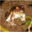

In [ ]:
# przyjrzenie się pierwszemu zdjęciu
index = 0
X_train[index]
# obraz jako tablica

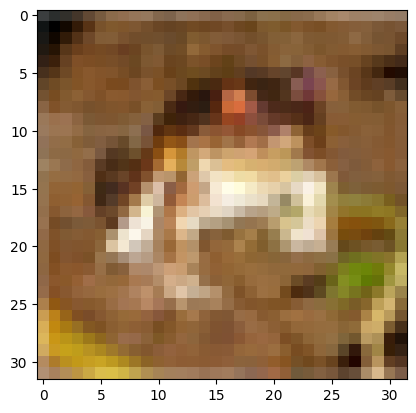

In [ ]:
# wyswietlenie juz jako obrazu
img = plt.imshow(X_train[index])

In [ ]:
# znalezienie etykiety obrazu
print('Etykieta klasy', y_train[index])

Etykieta klasy [6]


In [ ]:
# kazda liczba odpowiada nazyw klasy
classification = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Numer klasy:", y_train[index][0])
print("Nazwa klasy:", classification[y_train[index][0]])

Numer klasy: 6
Nazwa klasy: frog


In [ ]:
klasy, liczba = np.unique(y_train, return_counts=True)

for k, l in zip(klasy, liczba):
    print(f"{k} - {classification[k]}: {l} obrazów")

0 - airplane: 5000 obrazów
1 - automobile: 5000 obrazów
2 - bird: 5000 obrazów
3 - cat: 5000 obrazów
4 - deer: 5000 obrazów
5 - dog: 5000 obrazów
6 - frog: 5000 obrazów
7 - horse: 5000 obrazów
8 - ship: 5000 obrazów
9 - truck: 5000 obrazów


In [ ]:
y_train[:11]

array([[6],
       [9],
       [9],
       [4],
       [1],
       [1],
       [2],
       [7],
       [8],
       [3],
       [4]], dtype=uint8)

In [ ]:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

In [ ]:
print(y_train_one_hot)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


In [ ]:
print('zakodowana etykieta:', y_train_one_hot[index])

zakodowana etykieta: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [ ]:
X_train = X_train / 255
X_test = X_test / 255

In [ ]:
X_train[index]

array([[[0.20784314, 0.25490196, 0.20784314],
        [0.21176471, 0.24705882, 0.20392157],
        [0.21960784, 0.23529412, 0.19607843],
        ...,
        [0.18431373, 0.2       , 0.19607843],
        [0.16078431, 0.17647059, 0.17254902],
        [0.09411765, 0.10980392, 0.10588235]],

       [[0.18039216, 0.23137255, 0.16078431],
        [0.20784314, 0.24313725, 0.17647059],
        [0.21176471, 0.23137255, 0.17254902],
        ...,
        [0.16470588, 0.18039216, 0.17647059],
        [0.15294118, 0.16862745, 0.16470588],
        [0.10980392, 0.1254902 , 0.12156863]],

       [[0.17647059, 0.23137255, 0.14901961],
        [0.19607843, 0.23529412, 0.16078431],
        [0.18039216, 0.20392157, 0.13333333],
        ...,
        [0.14901961, 0.16470588, 0.16078431],
        [0.14117647, 0.15686275, 0.15294118],
        [0.11372549, 0.12941176, 0.1254902 ]],

       ...,

       [[0.27843137, 0.3254902 , 0.25882353],
        [0.29019608, 0.3254902 , 0.25882353],
        [0.31372549, 0

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [ ]:
IMG_SIZE = 96

X_train_tf = tf.image.resize(X_train, (IMG_SIZE, IMG_SIZE))
X_test_tf = tf.image.resize(X_test, (IMG_SIZE, IMG_SIZE))

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(10, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input,outputs=predictions)

In [ ]:
transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
transfer_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history_transfer = transfer_model.fit(
    X_train_tf,
    y_train_one_hot,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - accuracy: 0.6925 - loss: 0.8985 - val_accuracy: 0.7727 - val_loss: 0.6519
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7552 - loss: 0.7003 - val_accuracy: 0.7954 - val_loss: 0.5957
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7790 - loss: 0.6388 - val_accuracy: 0.7955 - val_loss: 0.5806
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7908 - loss: 0.6007 - val_accuracy: 0.8035 - val_loss: 0.5717
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8002 - loss: 0.5715 - val_accuracy: 0.8106 - val_loss: 0.5543
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.8051 - loss: 0.5506 - val_accuracy: 0.8045 - val_loss: 0.5579
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8158 - loss: 0.5246 - val_accuracy: 0.8103 - val_loss: 0.5500
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8196 - loss: 0.5096 - 

In [ ]:
loss, accuracy = transfer_model.evaluate( X_test_tf, y_test_one_hot)

print("Loss:", loss)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8160 - loss: 0.5426
Loss: 0.5426210761070251
Accuracy: 0.8159999847412109


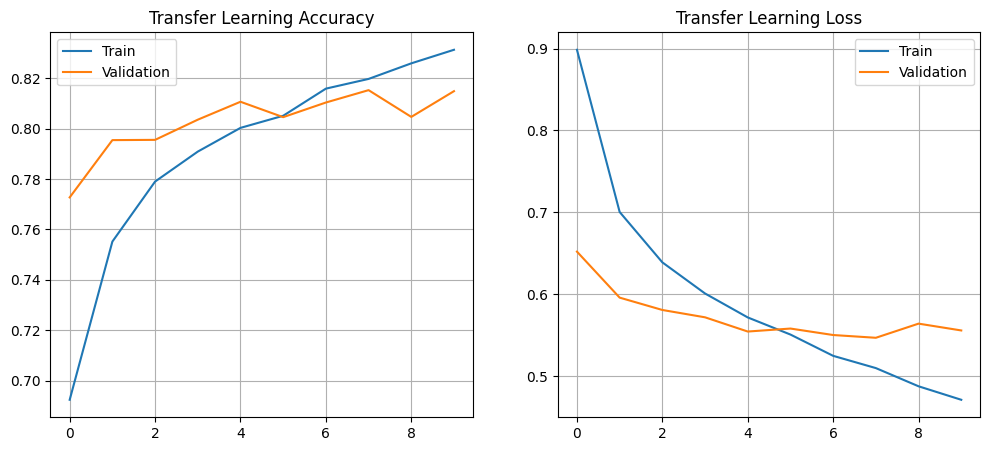

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])
plt.title("Transfer Learning Accuracy")
plt.legend(["Train","Validation"])
plt.grid()

plt.subplot(1,2,2)
plt.plot(history_transfer.history['loss'])
plt.plot(history_transfer.history['val_loss'])
plt.title("Transfer Learning Loss")
plt.legend(["Train","Validation"])
plt.grid()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


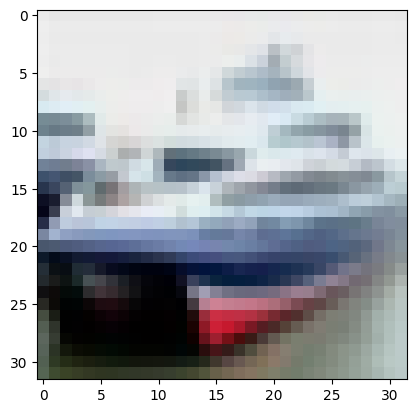

Prawdziwa klasa: ship
Przewidziana klasa: ship


In [ ]:
prediction = transfer_model.predict(X_test_tf)

index = 1

plt.imshow(X_test[index])
plt.show()

print("Prawdziwa klasa:", classification[y_test[index][0]])
print("Przewidziana klasa:", classification[np.argmax(prediction[index])])

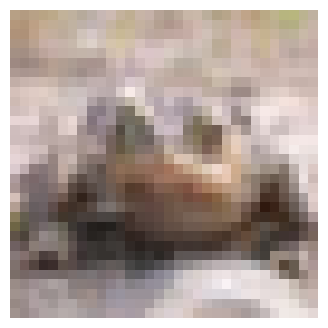

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prawdziwa klasa: frog
Predykcja modelu: airplane
Pewność: 0.30268705


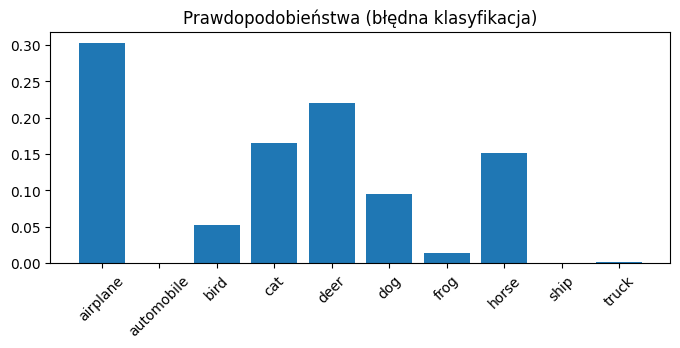

In [ ]:
idx = 8231 #@param {type:"slider", min:0, max:49999}

img = X_train[idx]

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.show()

pred = transfer_model.predict(np.array([img]))[0]

pred_class_idx = np.argmax(pred)
true_class_idx = y_train[idx][0]

if pred_class_idx != true_class_idx:

    print("Prawdziwa klasa:", classification[true_class_idx])
    print("Predykcja modelu:", classification[pred_class_idx])
    print("Pewność:", np.max(pred))

    plt.figure(figsize=(8,3))
    plt.bar(classification, pred)
    plt.xticks(rotation=45)
    plt.title("Prawdopodobieństwa - błędna klasyfikacja")
    plt.show()

else:
    print("Klasa:", classification[true_class_idx])
    print("Pewność:", np.max(pred))

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dog.jpg to dog.jpg


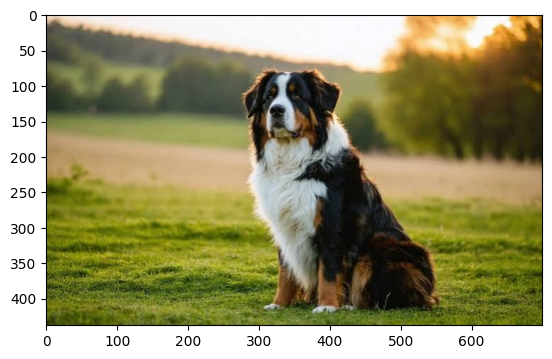

In [ ]:
new_image = plt.imread('dog.jpg')
img = plt.imshow(new_image)

In [ ]:
from skimage.transform import resize

IMG_SIZE = 96

resized_image = resize(
    new_image,
    (IMG_SIZE, IMG_SIZE, 3),
    anti_aliasing=True,
    preserve_range=True
)
resized_image = resized_image.astype(np.float32) / 255.0

image = np.expand_dims(resized_image, axis=0)

predictions = transfer_model.predict(np.array([resized_image]))
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[2.9168319e-04, 6.3001324e-04, 7.4653342e-02, 7.5772792e-02,
        1.0037948e-03, 8.1823856e-01, 1.8532877e-03, 2.3210673e-02,
        6.1071821e-04, 3.7350922e-03]], dtype=float32)

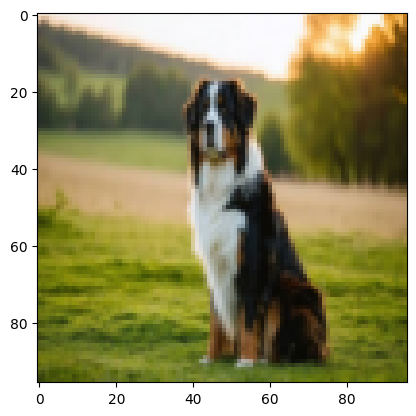

In [ ]:
img = plt.imshow(resized_image)

In [ ]:
list_index = [0,1,2,3,4,5,6,7,8,9]
x = predictions

for i in range(10):
  for j in range(10):
    if x[0][list_index[i]] > x[0][list_index[j]]:
      temp = list_index[i]
      list_index[i] = list_index[j]
      list_index[j] = temp

print(list_index)

[5, 3, 2, 7, 9, 6, 4, 1, 8, 0]


In [ ]:
for i in range(5):
  print(classification[list_index[i]], ':', round(predictions[0][list_index[i]] * 100, 2), '%')

dog : 81.82 %
cat : 7.58 %
bird : 7.47 %
horse : 2.32 %
truck : 0.37 %


### Podsumowanie
- Model osiągnął znacznie wyższą dokładność 81.6% niż wcześniejsze modele CNN ~63-71%. Już od pierwszej epoki osiąga wysokie wartości, co pokazuje skuteczność transfer learning.
Krzywa uczenia jest stabilna, brak dużego overfittingu. Model szybko konwerguje, ponieważ MobileNetV2 ma już wyuczone cechy takie jak krawędzie, tekstury, struktury,
uczona jest tylko końcowa warstwa klasyfikacyjna.
- Transfer learning znacząco poprawił jakość klasyfikacji w porównaniu do modeli budowanych od zera.
- Dla przykładowego obrazu psa (dog.jpg), model poprawnie przewidział klasę jako najwyższe prawdopodobieństwo niż pozostałe modele.